In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.model_selection import GroupShuffleSplit

In [4]:
df = pd.read_csv('data1C/final_data_1C.csv')
df.head()

,id,date,mood,activity,screen,call,sms,appCat.builtin,appCat.communication,appCat.entertainment,...,circumplex.valence_mean_3d_hist,mood_std_3d_hist,activity_std_3d_hist,screen_std_3d_hist,mood_change_today_vs_yesterday,activity_change_today_vs_yesterday,screen_change_today_vs_yesterday,day_of_week,is_weekend,mood_next_day
0,AS14.01,2014-03-23,6.80,0.142741,6773.832001,0.0,0.0,1286.246,5237.319,94.346,...,0.400000,0.000000,0.000000,0.000000,0.40,-0.094139,631.671002,6,1,6.00
1,AS14.01,2014-03-24,6.00,0.078961,15047.351001,10.0,0.0,866.956,9270.629,976.971,...,0.600000,0.282843,0.066566,446.658849,-0.80,-0.063780,8273.518999,0,0,6.75
2,AS14.01,2014-03-25,6.75,0.098374,15381.207999,0.0,1.0,1032.768,10276.751,68.206,...,0.400000,0.400000,0.079444,4969.113500,0.75,0.019413,333.856998,1,0,6.60
3,AS14.01,2014-03-26,6.60,0.101308,13585.707000,0.0,0.0,1167.497,8988.753,910.479,...,0.433333,0.448144,0.032694,4875.952876,-0.15,0.002934,-1795.500998,2,0,7.00
4,AS14.01,2014-03-27,7.00,0.159511,9360.814999,2.0,1.0,1229.327,6936.512,639.339,...,0.366667,0.396863,0.012144,954.959643,0.40,0.058202,-4224.892001,3,0,6.40


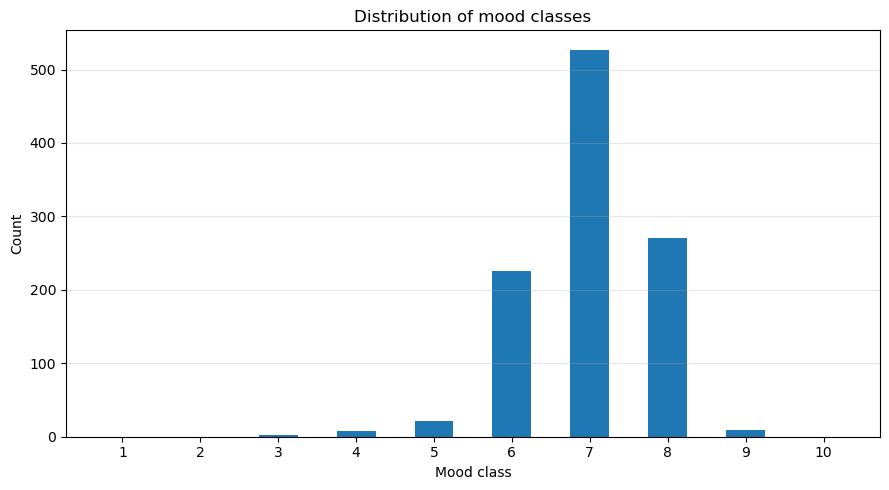

In [ ]:
df["mood_class"] = df["mood"].round().clip(1, 10).astype(int)

counts = df["mood_class"].value_counts().sort_index().reindex(range(1, 11), fill_value=0)

plt.figure(figsize=(9, 5))
plt.bar(counts.index, counts.values, width=0.5)
plt.title("Distribution of mood classes")
plt.xlabel("Mood class")
plt.ylabel("Count")
plt.xticks(range(1, 11))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
x = df.drop(columns="mood_next_day")

low  = df["mood_next_day"].quantile(0.33)
high = df["mood_next_day"].quantile(0.67)

def mood_to_class(x):
    if x <= low:  return 0
    elif x <= high: return 1
    else: return 2
y = df["mood_next_day"].apply(mood_to_class)
y.value_counts()

mood_next_day
0    402
2    345
1    316
Name: count, dtype: int64

In [ ]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(splitter.split(x, y, groups=df["id"]))

X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Verify no participant overlap
train_ids = df["id"].iloc[train_idx].unique()
test_ids  = df["id"].iloc[test_idx].unique()
print("Train participants:", len(train_ids))
print("Test participants:", len(test_ids))
print("Overlap:", set(train_ids) & set(test_ids))  

Train participants: 21
Test participants: 6
Overlap: set()
